In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
#Create Dataset

data = {
    "Income":[30,35,40,45,50,60,65,70,75,80],
    "SpendingScore":[20,25,30,35,40,65,70,75,80,85],
    "Customer":[0,0,0,0,0,1,1,1,1,1]
}

df = pd.DataFrame(data)

print(df)

   Income  SpendingScore  Customer
0      30             20         0
1      35             25         0
2      40             30         0
3      45             35         0
4      50             40         0
5      60             65         1
6      65             70         1
7      70             75         1
8      75             80         1
9      80             85         1


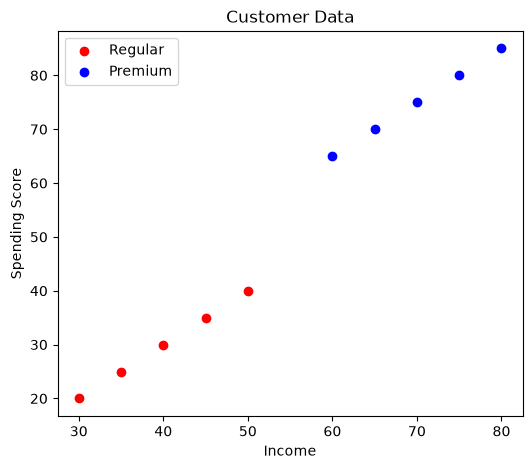

In [3]:
#Scatter Plot (Visualize Data)

plt.figure(figsize=(6,5))

plt.scatter(df[df["Customer"]==0]["Income"],
            df[df["Customer"]==0]["SpendingScore"],
            color="red",
            label="Regular")

plt.scatter(df[df["Customer"]==1]["Income"],
            df[df["Customer"]==1]["SpendingScore"],
            color="blue",
            label="Premium")

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")
plt.legend()

plt.show()

In [4]:
#Define X and y

X = df[["Income","SpendingScore"]]

y = df["Customer"]

In [5]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
#Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [7]:
#Train SVM Model

model = SVC(kernel='linear')

model.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [8]:
#Prediction

y_pred = model.predict(X_test)

print(y_pred)

[1 0]


In [9]:
#Accuracy

print("Accuracy :",accuracy_score(y_test,y_pred))

Accuracy : 1.0


In [10]:
#Confusion Matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[1 0]
 [0 1]]


In [11]:
#Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [12]:
#Predict New Customer
new_customer = scaler.transform([[55,60]])

prediction = model.predict(new_customer)

print(prediction)

[1]


c:\Users\Vansh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


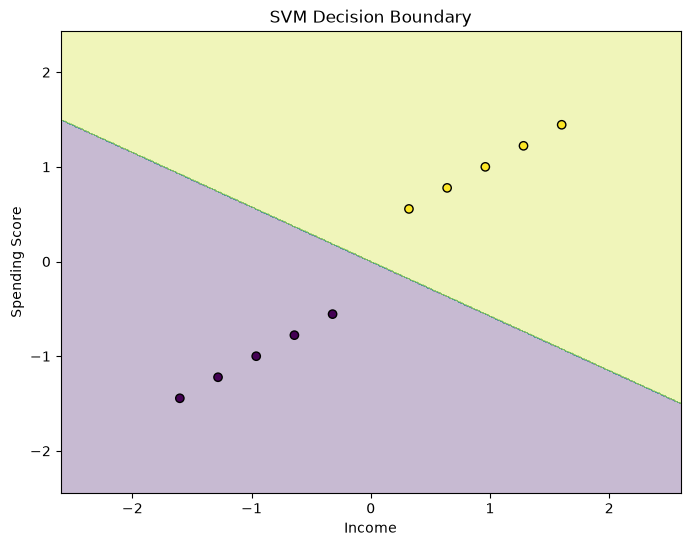

In [13]:
# Plot Decision Boundry
import numpy as np

X_set = np.vstack((X_train, X_test))
y_set = np.hstack((y_train, y_test))

X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1,
              X_set[:,0].max()+1,
              0.01),

    np.arange(X_set[:,1].min()-1,
              X_set[:,1].max()+1,
              0.01)
)

plt.figure(figsize=(8,6))

plt.contourf(
    X1,
    X2,
    model.predict(np.array([X1.ravel(),X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3
)

plt.scatter(
    X_set[:,0],
    X_set[:,1],
    c=y_set,
    edgecolors='k'
)

plt.xlabel("Income")
plt.ylabel("Spending Score")

plt.title("SVM Decision Boundary")

plt.show()

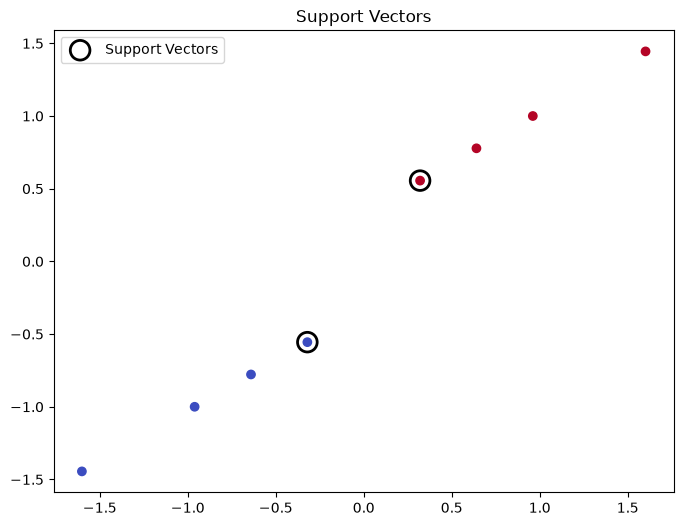

In [14]:
#Plot Support Vectors
plt.figure(figsize=(8,6))

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    cmap='coolwarm'
)

plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=200,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

plt.legend()

plt.title("Support Vectors")

plt.show()